MACHINE LEARNING ASSIGNMENT


---------------------------------------------------------------------------------------------------

The first step is to load the data for the assignment, in this case, "bank-additional.csv".


In [52]:
import pandas as pd

df = pd.read_csv("bank-additional.csv", sep=";")
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


---------------------------------------------------------------------------------------------------


Now I will use basic commands to show information, such as the dataset size, column names, missing value overviews, data types, and statistics for numerical variables.

In [53]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


----------------------------------------------------------------------------------------------------

I visualize at least two numerical and two categorical variables to understand distributions and potential imbalance.
These plots are exploratory only and do not involve model fitting.

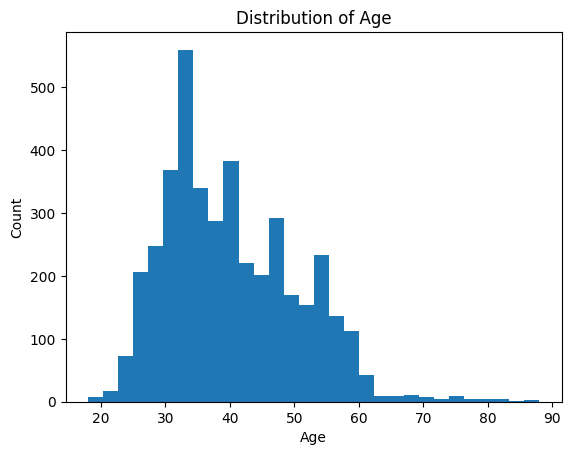

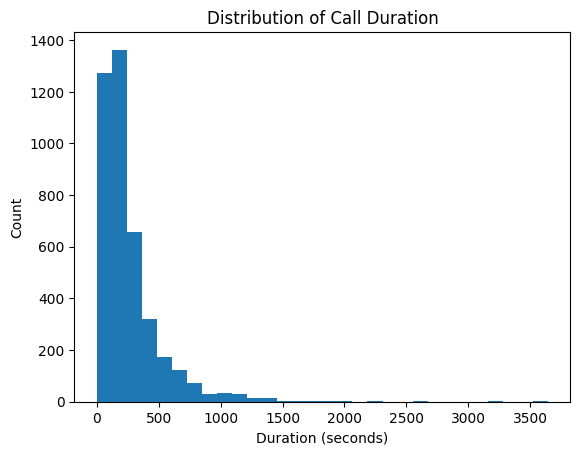

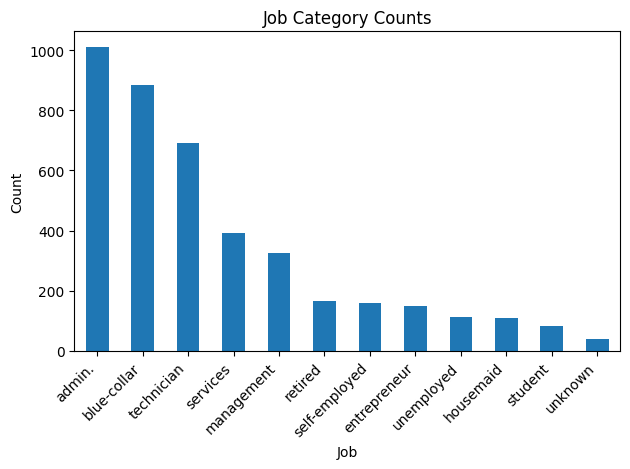

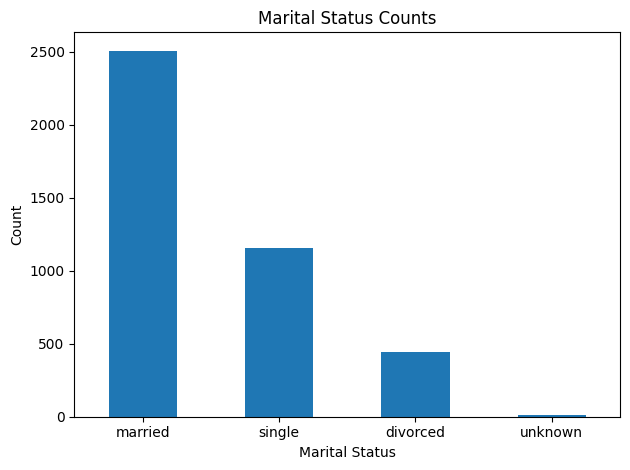

In [54]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["age"], bins=30)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.hist(df["duration"], bins=30)
plt.title("Distribution of Call Duration")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.show()


plt.figure()
df["job"].value_counts().plot(kind="bar")
plt.title("Job Category Counts")
plt.xlabel("Job")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure()
df["marital"].value_counts().plot(kind="bar")
plt.title("Marital Status Counts")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---------------------------------------------------------------------------------------------------

I will now identify the prediction target. Y is my prediction target, and the column contains 'yes'/'no' values that directly represent subscription outcomes. 
The dataset is imbalanced because there is a significant difference between the number of 'yes' and 'no' responses. 
An analysis of the class distribution shows that approximately 89% of clients did not subscribe, while only about 11% subscribed. 
This imbalance could lead to a misleading interpretation of the model's accuracy.

In [55]:
df["y"].value_counts()
df["y"].value_counts(normalize=True)

y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

---------------------------------------------------------------------------------------------------

I am going to separate the numerical and categorical variables because logistic regression requires numerical input. Categorical variables must be encoded, while numerical variables may need scaling.

In [56]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns
cat_cols = df.select_dtypes(include=["object", "string"]).columns

len(num_cols), len(cat_cols)
print("Numerical: ")
print(num_cols)

print("\nCategorical:")
print(cat_cols)

Numerical: 
Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='str')

Categorical:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='str')


In [57]:
(df == "unknown").sum().sort_values(ascending=False)

default           803
education         167
housing           105
loan              105
job                39
marital            11
age                 0
contact             0
month               0
day_of_week         0
duration            0
campaign            0
pdays               0
previous            0
poutcome            0
emp.var.rate        0
cons.price.idx      0
cons.conf.idx       0
euribor3m           0
nr.employed         0
y                   0
dtype: int64

I am now going to check for missing values.

In [58]:
df.isna().sum().sort_values(ascending=False)

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [59]:
(df == "unknown").sum().sort_values(ascending=False)

default           803
education         167
housing           105
loan              105
job                39
marital            11
age                 0
contact             0
month               0
day_of_week         0
duration            0
campaign            0
pdays               0
previous            0
poutcome            0
emp.var.rate        0
cons.price.idx      0
cons.conf.idx       0
euribor3m           0
nr.employed         0
y                   0
dtype: int64

I can confirm there are no explicit missing values, as they appear as 'unknown.' To understand the data, I am going to see how many times the 'unknown' value appears in each column.

---------------------------------------------------------------------------------------------------

I split the dataset before fitting preprocessing so validation andtest remain unseen during training.
Incorrect order example: fitting scaling/encoding/SMOTE on the full dataset before splitting would leak information and inflate evaluation results.

----------------------------------------------------------------------------------------------------

I will now separate X (features) and y (target). If they are not separated, the model might accidentally include the target variable 'y' among the features.

In [60]:
X = df.drop(columns=["y"])
y = df["y"]

X.shape, y.shape

((4119, 20), (4119,))

The dataset is split into training, validation, and test sets to ensure that model performance is evaluated on unseen data. The training set is used for learning model parameters and fitting preprocessing transformations, while the validation and test sets are used for evaluation. I am using a 70/30 split, where 70% of the data is allocated to the training set and 30% is reserved for validation and testing.

Since the dataset is imbalanced, I perform stratified splitting with respect to the target variable.

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

The temporary dataset is split into validation and test sets. The validation set is used to evaluate model performance, and I am going to split the temporary set equally (15% for validation and 15% for testing out of the 30% reserved).

In [62]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)
X_val.shape, X_test.shape

((618, 20), (618, 20))

---------------------------------------------------------------------------------------------------


Now I am going to verify the stratification correctly.

In [63]:
print("Training:")
print(y_train.value_counts(normalize=True))

print("\nValidation:")
print(y_val.value_counts(normalize=True))

print("\nTesting:")
print(y_test.value_counts(normalize=True))

Training:
y
no     0.890392
yes    0.109608
Name: proportion, dtype: float64

Validation:
y
no     0.889968
yes    0.110032
Name: proportion, dtype: float64

Testing:
y
no     0.891586
yes    0.108414
Name: proportion, dtype: float64


As I can see, the stratification worked.

---------------------------------------------------------------------------------------------------


Several categorical variables contain the category 'unknown,' which represents implicit missing values. Instead of removing these observations or imputing alternative values, 'unknown' will remain as a separate category. This decision is motivated by the possibility that the missingness itself may carry predictive information.

I am now going to separate the numerical and categorical variables again, but based on the training set. I define the preprocessing structure using training data only; this ensures that transformations applied later, such as encoding and scaling, are fitted using only information available during training.

In [64]:
num_cols = X_train.select_dtypes(include=["int64","float64"]).columns
cat_cols = X_train.select_dtypes(include=["object", "string"]).columns

len(num_cols), len(cat_cols)
print("Numerical: ")
print(num_cols)

print("\nCategorical:")
print(cat_cols)

Numerical: 
Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='str')

Categorical:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='str')


---------------------------------------------------------------------------------------------------

I am now moving to categorical encoding. Since logistic regression works only with numbers, I will use one-hot encoding. This strategy creates binary indicator variables for each category, allowing the linear model to learn separate coefficients without imposing artificial ordinal relationships. To avoid data leakage, the encoder is fitted only on the training set and then applied to the validation and test sets.

In [65]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoder.fit(X_train[cat_cols])

X_train_cat = encoder.transform(X_train[cat_cols])
X_val_cat = encoder.transform(X_val[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])


X_train_cat

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(2883, 53))

Numerical variables may have very different ranges. Since logistic regression is optimized using gradient-based methods and often includes regularization, feature scaling is applied to ensure that all numerical features contribute comparably during training. To avoid leakage, the scaler is fitted only on the training set and then applied to the validation and test sets.

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


scaler.fit(X_train[num_cols])

X_train_num = scaler.transform(X_train[num_cols])
X_val_num = scaler.transform(X_val[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

X_train_num.shape, X_val_num.shape, X_test_num.shape

((2883, 10), (618, 10), (618, 10))

Numerical and categorical variables are represented as separate transformed matrices: scaled numerical features and one-hot encoded categorical features. Since logistic regression expects a single feature matrix as input, I combine both to obtain the final design matrix for training, validation, and testing.

In [67]:
import numpy as np

X_train_prepared = np.hstack([X_train_num, X_train_cat])
X_val_prepared   = np.hstack([X_val_num, X_val_cat])
X_test_prepared  = np.hstack([X_test_num, X_test_cat])


X_train_prepared.shape, X_val_prepared.shape, X_test_prepared.shape

((2883, 63), (618, 63), (618, 63))

---------------------------------------------------------------------------------------------------


Now I am going to train a logistic regression classifier, as I want to test the number of sensible predictions produced.

In [68]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_prepared, y_train)
y_val_pred = log_reg.predict(X_val_prepared)

---------------------------------------------------------------------------------------------------


Precision, recall, and confusion matrix: precision measures how many predicted positives are actually correct, while recall measures how many real positives are identified correctly.

In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

acc = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred, pos_label="yes")
rec = recall_score(y_val, y_val_pred, pos_label="yes")
cm = confusion_matrix(y_val, y_val_pred, labels=["yes", "no"])

acc, prec, rec, cm

(0.919093851132686,
 0.7045454545454546,
 0.45588235294117646,
 array([[ 31,  37],
        [ 13, 537]]))

The model achieves a precision of 0.71 and a recall of 0.46 for the 'yes' class. 
Based on the confusion matrix, the model correctly identifies most non-subscribers but misses a substantial number of actual subscribers. 
This explains the moderate recall and indicates that improving detection of the minority class may be necessary.

---------------------------------------------------------------------------------------------------

Zero rule baseline: this provides the minimal performance any model should achieve. If logistic regression does not exceed this baseline, it is not learning useful patterns. The baseline achieves approximately 89% accuracy by always predicting the majority class. The logistic regression model achieves about 91.9% accuracy, slightly outperforming this baseline.

In [70]:
majority_class = y_train.value_counts().idxmax()
zero_rule_acc = (y_val == majority_class).mean()

majority_class, zero_rule_acc

('no', np.float64(0.889967637540453))

The dataset is imbalanced, which biases the model toward predicting the majority class. To address this, I apply SMOTE to the training set, generating synthetic minority examples. SMOTE is applied only after preprocessing and only on the training data to prevent leakage.

Only the training data was resampled, while the validation and test sets retain the original distribution.

In [71]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_prepared, y_train
)

y_train_balanced.value_counts()

y
no     2567
yes    2567
Name: count, dtype: int64

I am now going to retrain the model on the balanced data.

In [72]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

log_reg_balanced = LogisticRegression(max_iter=1000, random_state=42)
log_reg_balanced.fit(X_train_balanced, y_train_balanced)

y_val_pred_balanced = log_reg_balanced.predict(X_val_prepared)

accuracy_score(y_val, y_val_pred_balanced)
precision_score(y_val, y_val_pred_balanced, pos_label="yes")
recall_score(y_val, y_val_pred_balanced, pos_label="yes")
confusion_matrix(y_val, y_val_pred_balanced, labels=["yes","no"])



acc = accuracy_score(y_val, y_val_pred_balanced)
prec = precision_score(y_val, y_val_pred_balanced, pos_label="yes")
rec = recall_score(y_val, y_val_pred_balanced, pos_label="yes")
cm = confusion_matrix(y_val, y_val_pred_balanced, labels=["yes","no"])

acc, prec, rec, cm

(0.872168284789644,
 0.4566929133858268,
 0.8529411764705882,
 array([[ 58,  10],
        [ 69, 481]]))

After applying SMOTE, recall increased significantly (0.85), meaning the model now detects most subscribers. 
However, precision decreased (0.46), indicating more false positives, and overall accuracy slightly dropped. 
This demonstrates the precision–recall tradeoff.

In a marketing context, missing potential subscribers (false negatives) implies many lost opportunities. While increasing recall leads to more false positives, the cost of contacting uninterested clients is typically lower than the cost of missing true subscribers. 
Therefore, a model with higher recall rather than higher precision would be more suitable.


----------------------------------------------------------------------------------------------------

Feature selection combines conceptual reasoning and statistical analysis. 
I remove features that introduce leakage (duration) and inspect those with low variance.

I will start by removing duration.

In [73]:
X_train = X_train.drop(columns=["duration"])
X_val = X_val.drop(columns=["duration"])
X_test = X_test.drop(columns=["duration"])

After removing the duration feature due to temporal leakage, I rebuild the preprocessing pipeline using only the training data.

In [74]:
num_cols = X_train.select_dtypes(include=["int64","float64"]).columns
cat_cols = X_train.select_dtypes(include=["object", "string"]).columns

One-hot encoding:

In [75]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoder.fit(X_train[cat_cols])

X_train_cat = encoder.transform(X_train[cat_cols])
X_val_cat = encoder.transform(X_val[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])

Scaling numerical features (training):

In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train[num_cols])

X_train_num = scaler.transform(X_train[num_cols])
X_val_num = scaler.transform(X_val[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

Combine numerical and categorical:

In [77]:
import numpy as np

X_train_prepared = np.hstack([X_train_num, X_train_cat])
X_val_prepared   = np.hstack([X_val_num, X_val_cat])
X_test_prepared  = np.hstack([X_test_num, X_test_cat])

X_train_prepared.shape

(2883, 62)

After removing the duration variable due to temporal leakage, I rebuilt the preprocessing steps (encoding and scaling) using only the training data.
The final feature matrix now contains 62 features, reflecting the exclusion of the leaked variable.

----------------------------------------------------------------------------------------------------

Low-variance features change very little across examples and often add a limited predictive signal. If any feature has near-zero variance, I remove it consistently from all splits.

In [78]:
import pandas as pd

var_series = pd.Series(X_train[num_cols].var(), index=num_cols).sort_values()
var_series.head(10)

previous              0.314198
cons.price.idx        0.342768
emp.var.rate          2.446584
euribor3m             3.014293
campaign              6.868147
cons.conf.idx        21.430475
age                 107.446945
nr.employed        5481.697956
pdays             39049.991305
dtype: float64

Highly correlated numerical features can cause multicollinearity, making linear model coefficients unstable. I compute correlations using training data only.

In [79]:
import numpy as np

corr = X_train[num_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr_pairs = (
    upper.stack()
    .sort_values(ascending=False)
)

high_corr_pairs.head(15)

emp.var.rate    euribor3m         0.969648
euribor3m       nr.employed       0.942087
emp.var.rate    nr.employed       0.895815
                cons.price.idx    0.756447
cons.price.idx  euribor3m         0.654637
pdays           previous          0.607106
previous        nr.employed       0.519873
cons.price.idx  nr.employed       0.469817
previous        euribor3m         0.466142
                emp.var.rate      0.422470
pdays           nr.employed       0.402703
                euribor3m         0.316205
                emp.var.rate      0.282890
cons.conf.idx   euribor3m         0.256168
campaign        emp.var.rate      0.187127
dtype: float64

To reduce multicollinearity and improve coefficient stability, I retain 'euribor3m' and remove the other highly correlated features.

In [80]:
X_train = X_train.drop(columns=["emp.var.rate", "nr.employed"])
X_val   = X_val.drop(columns=["emp.var.rate", "nr.employed"])
X_test  = X_test.drop(columns=["emp.var.rate", "nr.employed"])

After doing this, I am going to preprocess everything to check if the features were efficiently removed.

In [81]:
num_cols = X_train.select_dtypes(include=["int64","float64"]).columns
cat_cols = X_train.select_dtypes(include=["object", "string"]).columns

In [82]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoder.fit(X_train[cat_cols])

X_train_cat = encoder.transform(X_train[cat_cols])
X_val_cat = encoder.transform(X_val[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])

In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train[num_cols])

X_train_num = scaler.transform(X_train[num_cols])
X_val_num = scaler.transform(X_val[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

In [84]:
import numpy as np

X_train_prepared = np.hstack([X_train_num, X_train_cat])
X_val_prepared   = np.hstack([X_val_num, X_val_cat])
X_test_prepared  = np.hstack([X_test_num, X_test_cat])

X_train_prepared.shape

(2883, 60)

Everything is in order.

----------------------------------------------------------------------------------------------------

I will retrain logistic regression on the updated feature set. Then, I will evaluate it on the validation section using accuracy, precision, recall, and the confusion matrix, and finally compare the SMOTE and non-SMOTE versions to observe the tradeoff.


This is the non-SMOTE code:

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_prepared, y_train)

y_val_pred = log_reg.predict(X_val_prepared)

acc  = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred, pos_label="yes")
rec  = recall_score(y_val, y_val_pred, pos_label="yes")
cm   = confusion_matrix(y_val, y_val_pred, labels=["yes","no"])

acc, prec, rec, cm

(0.9045307443365695,
 0.7647058823529411,
 0.19117647058823528,
 array([[ 13,  55],
        [  4, 546]]))

The refined model achieves high precision but very low recall.

----------------------------------------------------------------------------------------------------

Among the evaluated models, the SMOTE model provides significantly higher recall for the minority class. 
Therefore, I select the SMOTE model for final evaluation.


I am reapplying SMOTE to the updated training feature matrix and training logistic regression on the SMOTE training data.

In [86]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression


smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_prepared, y_train
)

log_reg_smote = LogisticRegression(max_iter=1000, random_state=42)
log_reg_smote.fit(X_train_balanced, y_train_balanced)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

The test set is used once to obtain an unbiased estimate of generalization performance.

In [87]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

y_test_pred = log_reg_smote.predict(X_test_prepared)

accuracy_score(y_test, y_test_pred), \
precision_score(y_test, y_test_pred, pos_label="yes"), \
recall_score(y_test, y_test_pred, pos_label="yes"), \
confusion_matrix(y_test, y_test_pred, labels=["yes","no"])

(0.7766990291262136,
 0.25517241379310346,
 0.5522388059701493,
 array([[ 37,  30],
        [108, 443]]))

On the unseen test set, the model achieves moderate recall, detecting over half of the actual subscribers. 
Precision is lower, indicating a substantial number of false positives.

----------------------------------------------------------------------------------------------------

This assignment showed how crucial it is to prepare data carefully. This includes preventing leakage, using stratified splitting, encoding, scaling, and managing class imbalance. The final logistic regression model, which used SMOTE, improved recall for the minority class. This fits with the marketing goal of identifying potential subscribers.